# Animal Faces Classification

## Dataset and Imports

In [ ]:
import opendatasets as ods
#ods.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:54<00:00, 13.3MB/s] 


In [44]:
import torch
import torch.nn as nn
from torch.optim import Adam, SGD
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


## Preprocessing Dataset

### Splitting

We need to split the dataset into train, validation, and test. In order to do so, we 
- read each image from the existing dataset, we append its path to a list, and its label to another list
- create a dataframe containing all the paths and labels
- individuate the unique labels, that is the classes in the dataset
- split the whole dataset into the three datasets

In [18]:
image_path = []
labels = []

for i in os.listdir('animal-faces/afhq'):
    for label in os.listdir(f'animal-faces/afhq/{i}'):
        for image in os.listdir(f'animal-faces/afhq/{i}/{label}'):
            image_path.append(f'animal-faces/afhq/{i}/{label}/{image}')
            labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ['image_path', 'label'])
print(data_df['label'].unique())
data_df.head(5)


<StringArray>
['dog', 'wild', 'cat']
Length: 3, dtype: str


,image_path,label
0,animal-faces/afhq/val/dog/pixabay_dog_003658.jpg,dog
1,animal-faces/afhq/val/dog/pixabay_dog_000691.jpg,dog
2,animal-faces/afhq/val/dog/pixabay_dog_002829.jpg,dog
3,animal-faces/afhq/val/dog/pixabay_dog_000265.jpg,dog
4,animal-faces/afhq/val/dog/flickr_dog_001041.jpg,dog


We use `DataFrame.sample()` to select a fraction of the whole data for each dataset. We use
- training: 0.7
- validation: 0.15
- test: 0.15

Before selecting the test dataset, we need to drop the indices of the train dataset elements from the full dataset, otherwise there will be duplicates, which is very bad for training, as the test accuracy will be distorted if the test set contains elements of the training set.

Finally, we drop the indices of the train set and the test set, and what remains will be the validation set.

In [19]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index).sample(frac = 0.5)
val = data_df.drop(train.index).drop(test.index)

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

Train: (11291, 2) | Val: (2419, 2) | Test: (2420, 2)


### Encoding and Transforming
We need to turn the string labels into numbers for the training. We do so using `LabelEncoder()`. by fitting the encoder to our train dataset, it records the labels of the dataset and their numerical equivalent.

Then we apply a **transform**, to ensure all images have the same properties, thus are equivalent and have the same weight inside the dataset:
- we resize the images so that they are all `128 x 128` pixels
- we convert it from a numpy matrix to a tensor
- we convert all the numbers inside the tensor to `torch,float` datatype

In [20]:
label_encoder = LabelEncoder()

label_encoder.fit(data_df["label"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

We define a custom image dataset to contain the images, inheriting from the `Dataset` class.
- the labels are created by turning the string labels in the dataframe into numerical (`int`) labels using the encoder with `transform`, and then the resulting list is converted into a PyTorch tensor and sent to the device
- the `__getitem()__` function takes in an index and returns the image as a `Pillow` `Image` object, after applying the eventual transform, and its numerical label.

In [21]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['label'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        image = image.to(device)

        return image, label

In [22]:
train_ds = CustomImageDataset(dataframe=train, transform=transform)
val_ds = CustomImageDataset(dataframe=val, transform=transform)
test_ds = CustomImageDataset(dataframe=test, transform=transform)

### Visualize Images
We can visualize the images in our dataset with matplotlib.

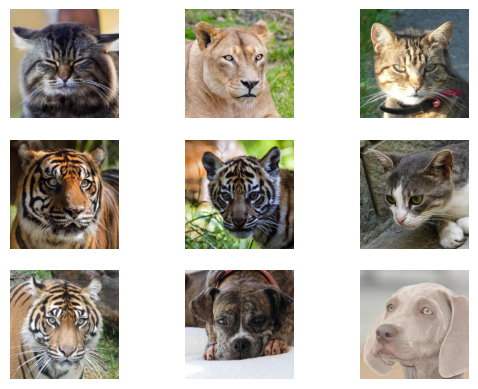

In [28]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n=1)['image_path'].iloc[0]).convert('RGB')
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')

plt.show()

## Building the Model

In [29]:
# Hyperparameters
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [30]:
# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

We create the model with
- *Convolution layers*: increase the number of features (`3 -> 32 -> 64 -> 128`) without reducing the image size 
- *Max-pooling layers*: also called dimension-reduction layers, which reduce the image size without changing the number of features
- *Flatten layer* this layer reduces the image tensor object into one big 1d vector

After the *flatten layer*, the vector goes into a fully-connected mlp and then a normal dense/linear layer, and finally the output layer

In [37]:
# Creating model class
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) 

        # Pooling layer
        self.pooling = nn.MaxPool2d(2,2)

        # Activation function
        self.relu = nn.ReLU()

        # flatten layer
        self.flatten = nn.Flatten()

        # linear layer
        self.linear = nn.Linear(128*16*16, 128) # 128 out_features is an arbitrary choice

        # output layer
        self.output = nn.Linear(128, len(data_df['label'].unique()))

    def forward(self, x): # x is (3, 128, 128)
        x = self.conv1(x) # (32, 128, 128)
        x = self.pooling(x) # (32, 64, 64)
        x = self.relu(x) # (32, 64, 64) - does not change sizes or amount of features
 
        x = self.conv2(x) # (64, 64, 64)
        x = self.pooling(x) # (64, 32, 32)
        x = self.relu(x) # (64, 32, 32)

        x = self.conv3(x) # (128, 64, 64)
        x = self.pooling(x) # (128, 16, 16)
        x = self.relu(x) # (128, 16, 16)

        x = self.flatten(x) # (128*16*16) 
        x = self.linear(x) # in (128*16*16) out 128
        x = self.output(x) # in 128 out 3

        return x

In [50]:
# Creating model object
model = Net().to(device)

In [43]:
# Check model summary
summary(model, input_data=(3,128,128))
summary

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 128, 128]        896
├─MaxPool2d: 1-2                         [-1, 32, 64, 64]          --
├─ReLU: 1-3                              [-1, 32, 64, 64]          --
├─Conv2d: 1-4                            [-1, 64, 64, 64]          18,496
├─MaxPool2d: 1-5                         [-1, 64, 32, 32]          --
├─ReLU: 1-6                              [-1, 64, 32, 32]          --
├─Conv2d: 1-7                            [-1, 128, 32, 32]         73,856
├─MaxPool2d: 1-8                         [-1, 128, 16, 16]         --
├─ReLU: 1-9                              [-1, 128, 16, 16]         --
├─Flatten: 1-10                          [-1, 32768]               --
├─Linear: 1-11                           [-1, 128]                 4,194,432
├─Linear: 1-12                           [-1, 3]                   387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable pa

<function torchsummary.torchsummary.summary(model: torch.nn.modules.module.Module, input_data: Union[torch.Tensor, torch.Size, Sequence[torch.Tensor], Sequence[Union[int, Sequence[Any], torch.Size]], NoneType] = None, *args: Any, batch_dim: Optional[int] = 0, branching: bool = True, col_names: Optional[Iterable[str]] = None, col_width: int = 25, depth: int = 3, device: Optional[torch.device] = None, dtypes: Optional[List[torch.dtype]] = None, verbose: int = 1, **kwargs: Any) -> torchsummary.model_statistics.ModelStatistics>

In [51]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

## Training the Model

In [52]:
total_loss_train_list = []
total_loss_validation_list = []
total_acc_train_list = []
total_acc_validation_list = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_validation = 0
    total_loss_validation = 0

    for inputs, labels in train_loader:
        prediction = model(inputs).squeeze(1)
        
        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_train += batch_acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for inputs, labels in val_loader:
            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_validation += batch_loss.item()

            batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

            total_acc_validation += batch_acc

    total_loss_train_list.append(round(total_loss_train/1000, 4))
    total_acc_train_list.append(round(total_acc_train/train_ds.__len__() * 100, 4))

    total_loss_validation_list.append(round(total_loss_validation/1000, 4))
    total_acc_validation_list.append(round(total_acc_validation/val_ds.__len__() * 100, 4))

    print(f'''Epoch: {epoch+1} | Train Loss: {round(total_loss_train/1000, 4)} | Train Acc: {round(total_acc_train/train_ds.__len__() * 100, 4)} | Val Loss: {round(total_loss_validation/1000, 4)} | Val Acc: {round(total_acc_validation/val_ds.__len__() * 100, 4)}''')



Epoch: 1 | Train Loss: 0.3447 | Train Acc: 79.4969 | Val Loss: 0.0338 | Val Acc: 92.3522
Epoch: 2 | Train Loss: 0.1339 | Train Acc: 93.3044 | Val Loss: 0.0255 | Val Acc: 94.0885
Epoch: 3 | Train Loss: 0.0907 | Train Acc: 95.368 | Val Loss: 0.0188 | Val Acc: 95.742
Epoch: 4 | Train Loss: 0.0657 | Train Acc: 96.6611 | Val Loss: 0.0189 | Val Acc: 95.7834
Epoch: 5 | Train Loss: 0.0506 | Train Acc: 97.5201 | Val Loss: 0.0205 | Val Acc: 95.246


KeyboardInterrupt: 

## Testing the Model

In [53]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_loader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_test += batch_loss.item()

        batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_test += batch_acc

print(f"Test Acc: {round(total_acc_test/test_ds.__len__() * 100, 4)}")
        

Test Acc: 95.8264


## Visualization

We can see that there is somewhat of an overfitting, as the training accuracy is visibly higher than the validation accuracy. 

In order to change this tendency, we can try simplifying the model, by reducing the number of layers or the number of features, or changing optimizer, such as opting for `SGD` instead of `Adam`.

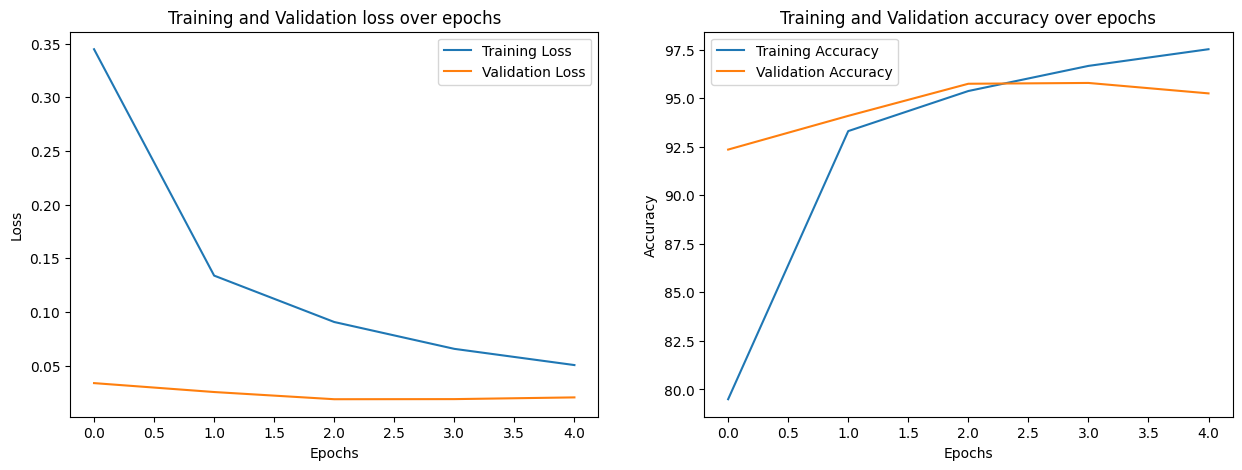

In [54]:
fig, axs = plt.subplots(nrows = 1, ncols=2, figsize=(15,5))

axs[0].plot(total_loss_train_list, label = 'Training Loss')
axs[0].plot(total_loss_validation_list, label = 'Validation Loss')
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
#axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_list, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_list, label = 'Validation Accuracy')
axs[1].set_title("Training and Validation accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
#axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()

## Single Prediction
We can test the model by downloading an image, applying our transform on it to reduce its properties to those of the training set images, and making inference on it. The steps are:
1. Read the image
2. Transform the image
3. Unsqueeze the image to add the batch dimension (otherwise the model gives an error)
4. Make inference
5. Apply the reverse transform by label encoder to get final string label

In [57]:
def predict_image(image_path):
    with torch.no_grad():
        # Read Image
        image = Image.open(image_path).convert('RGB')
        # Transform Image
        image = transform(image).to(device)
        # Unsqueeze 
        image = image.unsqueeze(0)
        # Make Inference
        pred = torch.argmax(model(image), axis=1).item()
        # Inverse Transform
        label = label_encoder.inverse_transform([pred])

    return label

In [58]:
predict_image('cat.jpeg')

array(['cat'], dtype=object)